In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

### Noise Schedule + Markov-Chain

In [8]:
def linear_schedule(T, beta_s=1e-4, beta_e=0.02):
    # beta_s ~ beta_e 선형 증가
    return np.linspace(beta_s, beta_e, T)

def quadratic_schedule(T, beta_s=1e-4, beta_e=0.02):
    return np.linspace(beta_s**0.5, beta_e**0.5, T)**2

def sigmoid_schedule(T, beta_s=1e-4, beta_e=0.02):
    x = np.linspace(-6, 6, T)
    return (1 / (1+np.exp(-x))) * (beta_e - beta_s) + beta_s

def forward_markov(x0, beta_sch, save_steps):
    results = {0: x0}
    x = x0

    for t_idx, beta in enumerate(beta_sch):
        t = t_idx + 1
        eps = np.random.randn(*x.shape)
        x = np.sqrt(1.0 - beta)*x + np.sqrt(beta)*eps

        if t in save_steps:
            results[t] = x.copy()

    return results

### SDE
$$
dx = -\frac{1}{2} \beta (t)xdt + \sqrt{\beta(t)}dw
$$
$$
x_{t+1}=\left(1-\frac{1}{2} \beta_t \Delta t \right)x_t + \sqrt{\beta_t \Delta t} \epsilon
$$

In [ ]:
def forward_SDE(x0, beta_sch, save_steps, dt=1.0):
    results = {0: x0.copy()}
    x = x0.copy()

    for t_idx, beta in enumerate(beta_sch):
        t = t_idx + 1
        drift = -0.5 * beta * dt * x
        diffusion = np.sqrt(beta * dt) * np.random.randn(*x.shape)
        x = x + drift + diffusion

        if t in save_steps:
            results[t] = x.copy()

    return results

In [9]:
n_samples = 1000
data, _ = make_swiss_roll(n_samples, noise=0.1)
x0 = data[:, [0, 2]]
x0 = (x0 - x0.mean(0)) / x0.std(0)

T = 1000
save_steps = {0, 100, 200, 400, 600, 800, 1000}

schedules = {
    "linear":    linear_schedule(T),
    "quadratic": quadratic_schedule(T),
    "sigmoid":   sigmoid_schedule(T),
}

markov_res = {name: forward_markov(x0, sch, save_steps) for name, sch in schedules.items()}
sde_res    = {name: forward_SDE(x0,    sch, save_steps) for name, sch in schedules.items()}

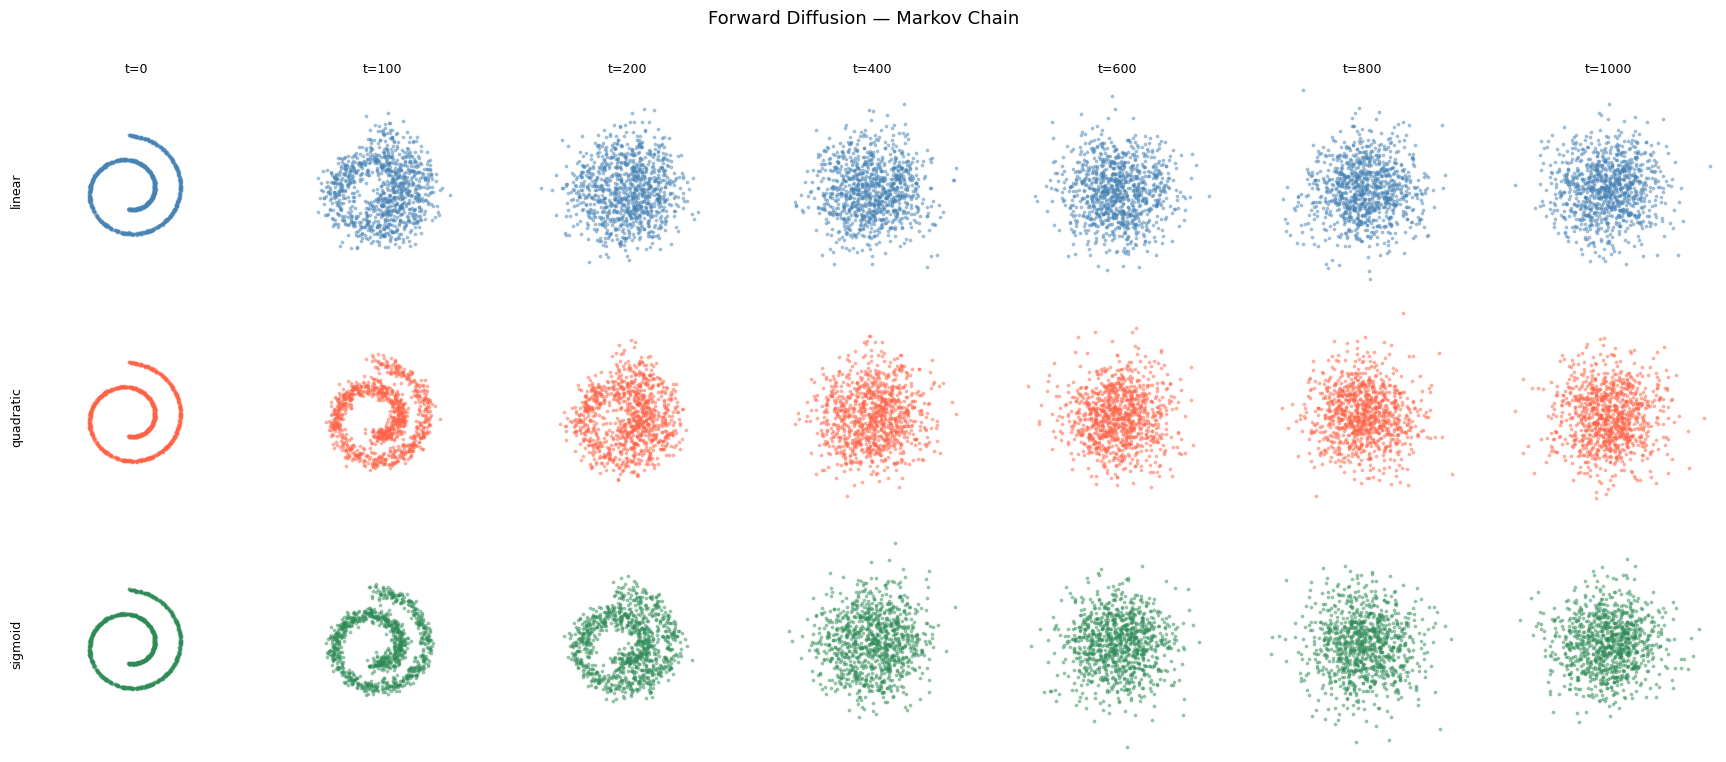

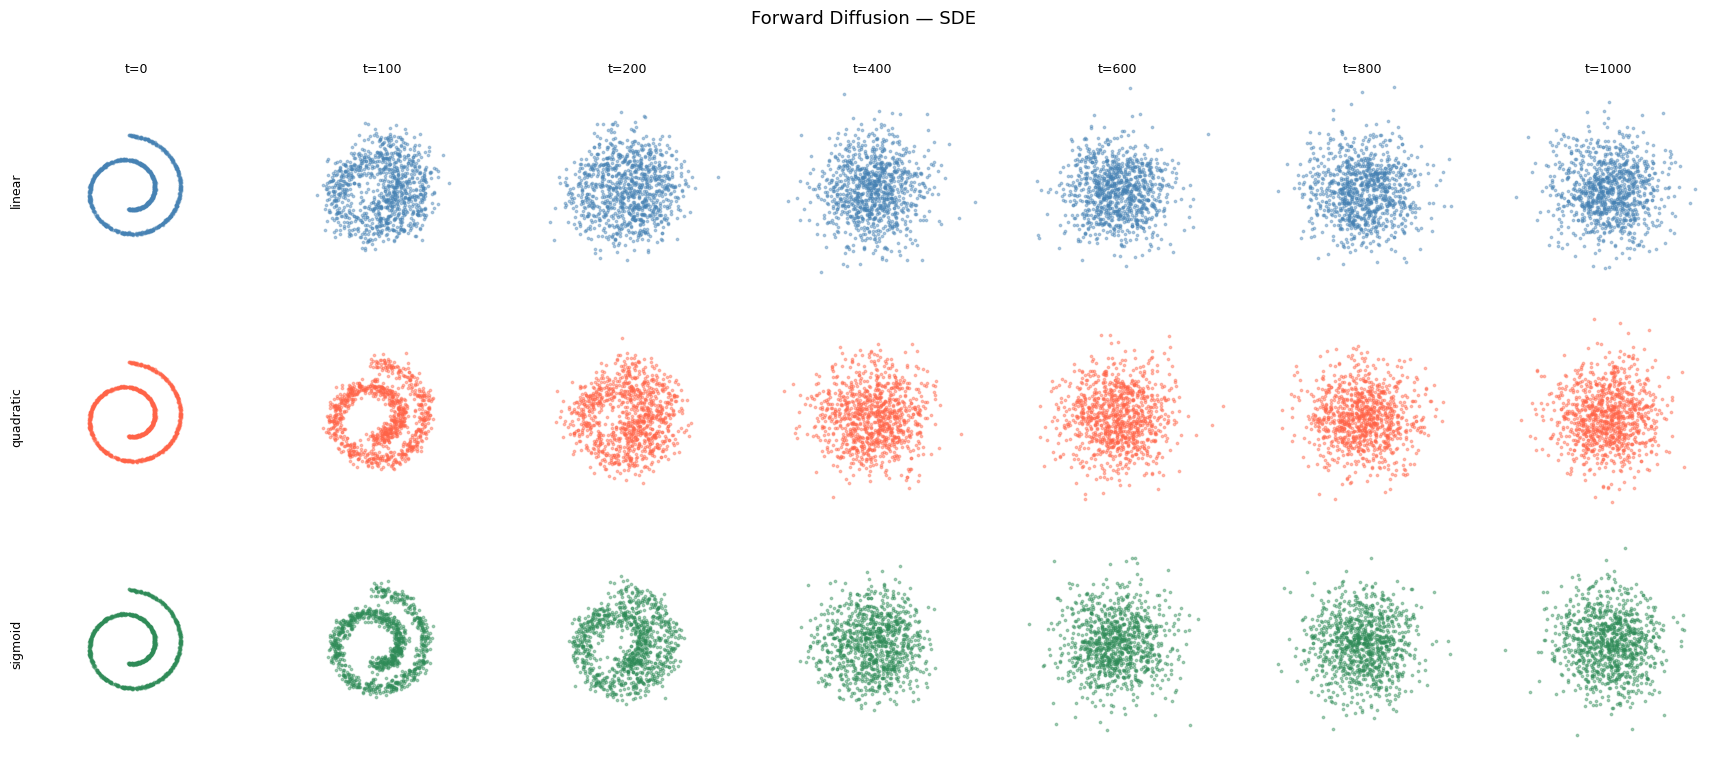

In [10]:
def plot_forward(results_dict, title):
    sched_names = list(results_dict.keys())
    steps = sorted(next(iter(results_dict.values())).keys())
    n_rows, n_cols = len(sched_names), len(steps)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows))
    colors = {"linear": "steelblue", "quadratic": "tomato", "sigmoid": "seagreen"}

    for r, name in enumerate(sched_names):
        for c, t in enumerate(steps):
            ax = axes[r, c]
            pts = results_dict[name][t]
            ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4, c=colors[name])
            ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
            ax.set_aspect("equal"); ax.axis("off")
            if r == 0:
                ax.set_title(f"t={t}", fontsize=9)
            if c == 0:
                ax.set_ylabel(name, fontsize=9)
                ax.axis("on"); ax.set_yticks([]); ax.set_xticks([])
                ax.spines[:].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_forward(markov_res, "Forward Diffusion — Markov Chain")
plot_forward(sde_res,    "Forward Diffusion — SDE")